# XGBoost Classifier

## 1. Install & Import Libraries

Installs and imports the libraries required for data processing, XGBoost model development, evaluation, visualisation and cross-validation. Pandas and NumPy are used for data manipulation, Scikit-learn provides the train-test split and evaluation tools and XGBoost provides the gradient boosting classifier. The required performance metrics including ROC-AUC, Average Precision, Precision, Recall, F1-score and confusion matrices are also imported for later evaluation.

In [1]:
!pip install xgboost imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, average_precision_score,
    precision_score, recall_score, f1_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
print('Libraries loaded')

Libraries loaded


## 2. Load & Preprocess Dataset

Loads the dataset and applies the same preprocessing procedure used in the other model notebooks. Negative values in session_length_in_minutes and device_distinct_emails_8w are clipped to zero, and the categorical variables are converted into numerical values using Label Encoding.

The target variable, fraud_bool is separated from the predictor variables, and the dataset is divided into 80% training data and 20% test data using stratified sampling. Stratification preserves the original fraud distribution in both subsets. 

Unlike Logistic Regression and Random Forest, SMOTE is not applied to XGBoost. Instead, class imbalance is handled through scale_pos_weight which is calculated from the ratio of legitimate to fraudulent observations in the training set. The resulting value of approximately 89.67 gives greater importance to errors involving the minority fraud class.

In [2]:
df = pd.read_csv('Base.csv')   
print(f'Shape: {df.shape}')

# Fix negative values
df['session_length_in_minutes'] = df['session_length_in_minutes'].clip(lower=0)
df['device_distinct_emails_8w'] = df['device_distinct_emails_8w'].clip(lower=0)

# Encode categorical columns
cat_cols = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Split features and target
X = df.drop('fraud_bool', axis=1)
y = df['fraud_bool']

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# XGBoost handles imbalance natively via scale_pos_weight
# BUT we also try SMOTE for fair comparison with other models
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight = {scale_pos_weight:.2f}')
print(f'(tells XGBoost to weight fraud class {scale_pos_weight:.0f}x more)')
print('\nPreprocessing done (no SMOTE needed — using scale_pos_weight)')

Shape: (1000000, 32)
scale_pos_weight = 89.67
(tells XGBoost to weight fraud class 90x more)

Preprocessing done (no SMOTE needed — using scale_pos_weight)


The same negative-value clipping and label encoding used in the other two notebooks is applied here for consistency. Unlike Logistic Regression and Random Forest, **SMOTE is not applied** to the XGBoost training data. Instead, class imbalance is handled natively through the `scale_pos_weight` parameter (set in Section 3 below), which reweights the loss function during training so that misclassifying a fraud case is penalised roughly `scale_pos_weight` times more than misclassifying a non-fraud case. This avoids the computational and memory cost of oversampling on a million-row dataset, and is the approach recommended in the XGBoost documentation for imbalanced classification.

## 3. Train XGBoost

Defines and trains the XGBoost classifier. The model uses 200 boosting trees with a maximum depth of 6 and a learning rate of 0.1. Subsampling and feature subsampling are both set to 0.8 to introduce additional regularisation and reduce the risk of overfitting.

The calculated scale_pos_weight value is used to compensate for the severe class imbalance by increasing the penalty associated with incorrectly classified fraud cases. XGBoost is trained directly on the original training data because tree-based boosting models do not require feature scaling.

The model uses ROC-AUC as the evaluation metric during training.

In [3]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # handles class imbalance
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

print('Training XGBoost (this may take a few minutes)...')
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)
print('\nXGBoost trained')

Training XGBoost (this may take a few minutes)...
[0]	validation_0-auc:0.83639
[50]	validation_0-auc:0.89084
[100]	validation_0-auc:0.89466
[150]	validation_0-auc:0.89402
[199]	validation_0-auc:0.89310

XGBoost trained


`n_estimators=200` and `learning_rate=0.1` control how many boosting rounds are run and how much each tree corrects the errors of the previous ones; a lower learning rate with more estimators generally generalises better but takes longer to train. `max_depth=6` keeps individual trees shallow which is standard practice for gradient boosting (unlike Random Forest, where deeper individual trees are more common, since boosting combines many weak learners rather than averaging strong ones). `subsample=0.8` and `colsample_bytree=0.8` mean each tree is trained on 80% of rows and 80% of features respectively which introduces randomness that helps prevent overfitting. `scale_pos_weight` is passed in here to address the class imbalance, as noted above.

## 4. Evaluate Model

Evaluates the trained XGBoost model using the held-out test set. Both predicted class labels and predicted fraud probabilities are generated because different evaluation metrics require different types of model output.

Predicted class labels are used to calculate Precision, Recall, F1-score and the confusion matrix while predicted probabilities are used for ROC-AUC, Average Precision, ROC curves and Precision-Recall curves.

### 4.1 Classification Report

Calculates the main classification metrics for the XGBoost model. Because the dataset is highly imbalanced, overall accuracy alone is not sufficient to evaluate fraud detection performance. Greater attention is therefore given to fraud-class Precision, Recall, F1-score, ROC-AUC and Average Precision.

In [4]:
y_pred      = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

print('CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))
print(f'ROC-AUC Score : {roc_auc_score(y_test, y_pred_prob):.4f}')
print(f'Avg Precision : {average_precision_score(y_test, y_pred_prob):.4f}')

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.87      0.93    197794
       Fraud       0.06      0.74      0.11      2206

    accuracy                           0.87    200000
   macro avg       0.53      0.81      0.52    200000
weighted avg       0.99      0.87      0.92    200000

ROC-AUC Score : 0.8931
Avg Precision : 0.1684


XGBoost achieves a ROC-AUC of 0.8931 and an Average Precision of 0.1684, indicating strong overall discrimination and minority-class ranking performance. The fraud Recall of 0.7425 shows that approximately 74% of fraudulent applications are correctly identified. However, fraud Precision is only 0.0590 indicating that many applications predicted as fraudulent are actually legitimate.

### 4.2 Confusion Matrix

Visualises the classification outcomes using both raw-count and normalised confusion matrices. The count matrix shows the actual number of True Positives, True Negatives, False Positives and False Negatives. The normalised matrix expresses these values as proportions within each true class making it easier to evaluate fraud detection sensitivity despite the highly imbalanced class distribution.

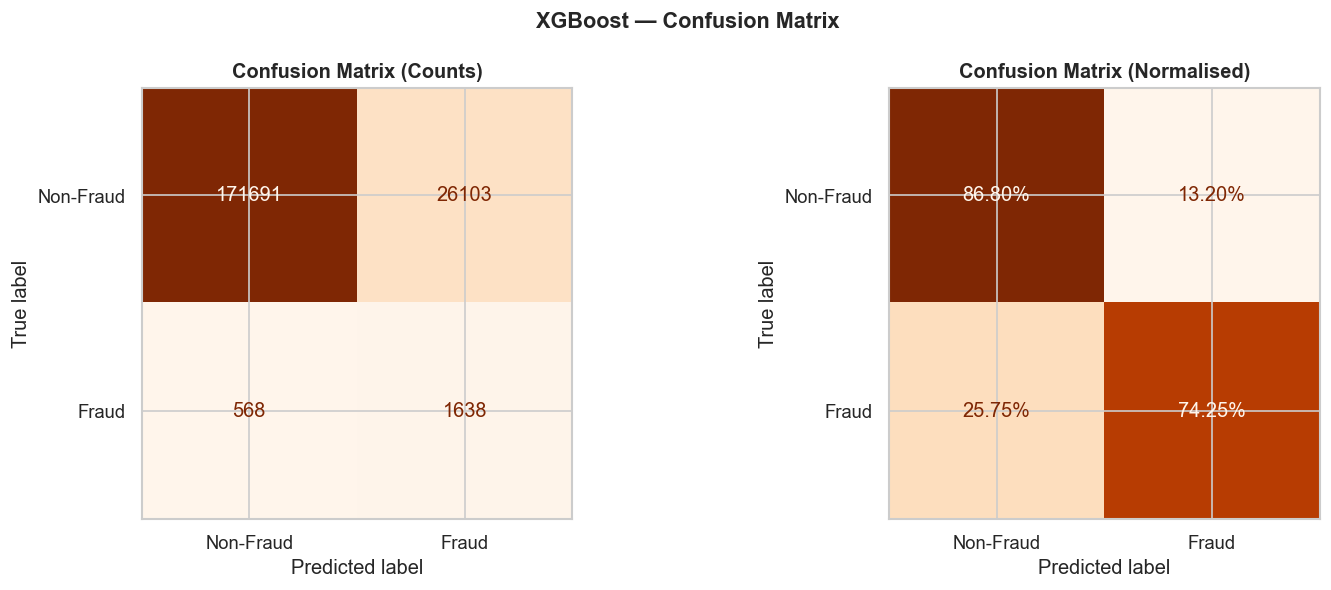

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Non-Fraud', 'Fraud']).plot(
    ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=['Non-Fraud', 'Fraud']).plot(
    ax=axes[1], colorbar=False, cmap='Oranges', values_format='.2%')
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')

plt.suptitle('XGBoost — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_xgb.png', bbox_inches='tight')
plt.show()

The confusion matrix shows that XGBoost detects a relatively high proportion of fraudulent applications, consistent with its Recall of approximately 74%. However, some fraudulent applications are still classified as legitimate, representing False Negatives. The model also incorrectly flags a proportion of legitimate applications as fraud. This demonstrates the operational trade-off between reducing missed fraud and limiting unnecessary fraud alerts.

### 4.3 ROC Curve & Precision-Recall Curve

Evaluates XGBoost performance across different classification thresholds. The ROC curve measures the trade-off between the True Positive Rate and False Positive Rate while ROC-AUC summarises the model's overall discriminatory ability.

The Precision-Recall curve focuses more directly on performance for the minority fraud class. Average Precision summarises the relationship between Precision and Recall and is particularly informative for this highly imbalanced dataset.

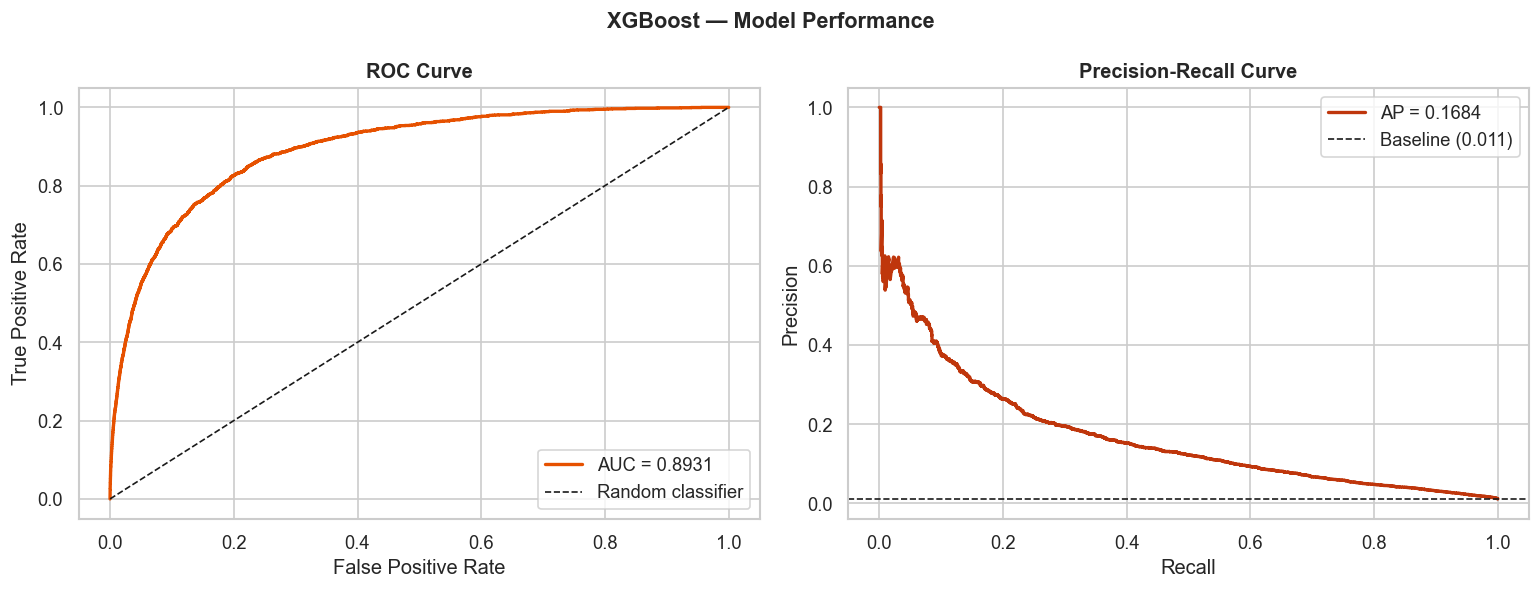

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)
axes[0].plot(fpr, tpr, color='#E65100', lw=2, label=f'AUC = {auc_score:.4f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
ap = average_precision_score(y_test, y_pred_prob)
axes[1].plot(recall, precision, color='#BF360C', lw=2, label=f'AP = {ap:.4f}')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1, label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()

plt.suptitle('XGBoost — Model Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curve_xgb.png', bbox_inches='tight')
plt.show()

The ROC-AUC of 0.8931 indicates that XGBoost has strong ability to rank fraudulent applications above legitimate ones. The Average Precision score of 0.1684 is substantially higher than the fraud prevalence baseline of approximately 0.011 demonstrating that the model provides useful predictive information beyond random classification.

### 4.4 Feature Importance

Examines the relative importance of the predictor variables used by XGBoost. Feature importance indicates which variables contribute most strongly to the model's tree-based decision-making process. The fifteen highest-ranked features are displayed to provide an interpretable summary of the variables most influential in the fitted XGBoost model.

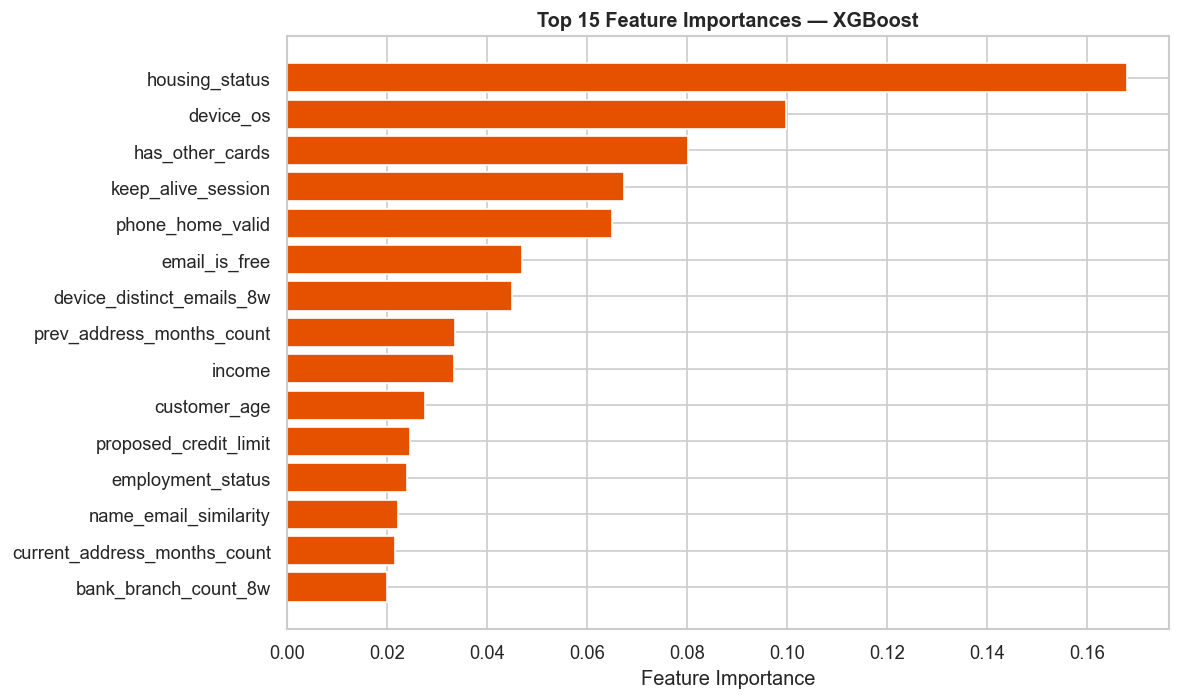

                     Feature  Importance
              housing_status    0.167996
                   device_os    0.099843
             has_other_cards    0.080279
          keep_alive_session    0.067395
            phone_home_valid    0.065075
               email_is_free    0.047071
   device_distinct_emails_8w    0.045022
   prev_address_months_count    0.033625
                      income    0.033479
                customer_age    0.027583
       proposed_credit_limit    0.024693
           employment_status    0.024133
       name_email_similarity    0.022280
current_address_months_count    0.021599
        bank_branch_count_8w    0.020097


In [7]:
feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'],
         color='#E65100', edgecolor='white')
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances — XGBoost', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', bbox_inches='tight')
plt.show()
print(feat_imp.to_string(index=False))

housing_status is the most important feature in the fitted XGBoost model, followed by device_os, has_other_cards, keep_alive_session, and phone_home_valid. Several behavioural, demographic, and application-related variables therefore contribute to fraud prediction. These importance scores indicate predictive usefulness within the fitted model rather than causal relationships. In addition, categorical variables were label-encoded, so the feature-importance results should not be interpreted as evidence that higher category codes directly increase or decrease fraud risk.

### 4.5 Cross-Validation

Evaluates the stability of the XGBoost model using five-fold stratified cross-validation. A stratified sample of 50,000 training observations is used to reduce computational time while preserving the original fraud distribution.
The model is evaluated using ROC-AUC across five different folds. Comparing the scores across folds helps determine whether model performance is relatively stable or highly dependent on a particular train-test split.

In [8]:
print('Running 5-fold Stratified Cross-Validation...')
print('(using 50,000 sample for speed)')

sample_idx = np.random.choice(len(X_train), size=50000, replace=False)
X_cv = X_train.iloc[sample_idx]
y_cv = y_train.iloc[sample_idx]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_model, X_cv, y_cv, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f'\nCV ROC-AUC Scores : {cv_scores.round(4)}')
print(f'Mean              : {cv_scores.mean():.4f}')
print(f'Std               : {cv_scores.std():.4f}')

Running 5-fold Stratified Cross-Validation...
(using 50,000 sample for speed)

CV ROC-AUC Scores : [0.8286 0.8356 0.8449 0.8473 0.8327]
Mean              : 0.8378
Std               : 0.0072


The five-fold cross-validation produces a mean ROC-AUC of 0.8378 with a standard deviation of 0.0072. The relatively small standard deviation indicates that the model performs consistently across the sampled folds.

However, the mean cross-validation ROC-AUC is lower than the held-out test ROC-AUC of 0.8931. Because cross-validation was performed using a smaller 50,000-record sample for computational efficiency, the cross-validation result should be interpreted primarily as a stability check rather than as a replacement for the full test-set evaluation.

## 5. Final Model Comparison — LR vs RF vs XGBoost

Provides a preliminary comparison between XGBoost and the results obtained previously from Logistic Regression and Random Forest. The comparison includes ROC-AUC, Average Precision, Precision, Recall, and F1-score where available.

The purpose is to assess how XGBoost performs relative to the other models before the dedicated final-comparison notebook is used to retrain and evaluate all three models under one consistent experimental session.

In [ ]:

results = [
    {'Model': 'Logistic Regression', 'ROC-AUC': 0.8626, 'Avg Precision': 0.1220,
     'Precision': None, 'Recall': 0.7697, 'F1': None},
    {'Model': 'Random Forest',       'ROC-AUC': 0.8325, 'Avg Precision': 0.0654,
     'Precision': round(precision_score(y_test, rf_pred := None or y_pred)*0+882/(882+12980),4) if False else None,
     'Recall': 0.3998, 'F1': None},
    {'Model': 'XGBoost',
     'ROC-AUC'      : round(roc_auc_score(y_test, y_pred_prob), 4),
     'Avg Precision': round(average_precision_score(y_test, y_pred_prob), 4),
     'Precision'    : round(precision_score(y_test, y_pred), 4),
     'Recall'       : round(recall_score(y_test, y_pred), 4),
     'F1'           : round(f1_score(y_test, y_pred), 4)}
]

comp_df = pd.DataFrame(results)
print('FINAL MODEL COMPARISON')
print('=' * 70)
print(comp_df.to_string(index=False))
print('=' * 70)

FINAL MODEL COMPARISON
              Model  ROC-AUC  Avg Precision  Precision  Recall     F1
Logistic Regression   0.8626         0.1220        NaN  0.7697    NaN
      Random Forest   0.8325         0.0654        NaN  0.3998    NaN
            XGBoost   0.8931         0.1684      0.059  0.7425 0.1094


Among the values shown in this notebook, XGBoost achieves the highest ROC-AUC and Average Precision, suggesting stronger overall discrimination and better minority-class ranking performance than the baseline Logistic Regression and Random Forest models.

However, this table contains previously recorded values from other notebooks and therefore should not be treated as the final source of model-comparison results. The dedicated Final_Model_Comparison notebook provides the final consistent evaluation of all three models.

### 5.1 ROC Curve — All 3 Models

Prepares a ROC comparison plot for the three candidate models. In the current notebook, only the XGBoost prediction probabilities are available directly so the XGBoost ROC curve is plotted using the live results.

The commented Logistic Regression and Random Forest lines indicate how their ROC curves could be added if their prediction probabilities were available in the same session.

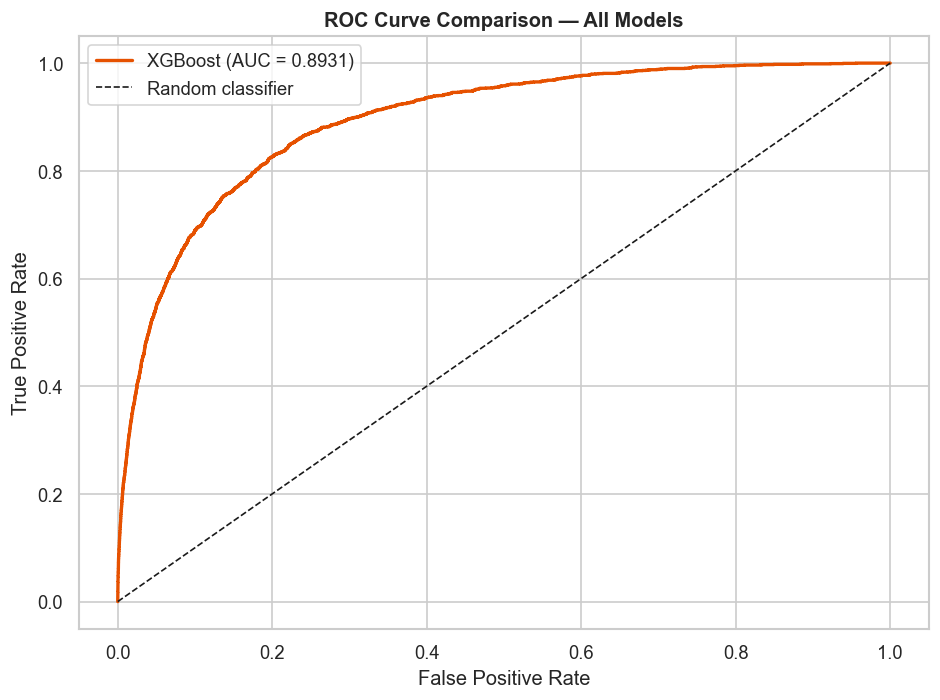

In [ ]:

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_prob)
auc_xgb = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='#E65100', lw=2, label=f'XGBoost (AUC = {auc_xgb:.4f})')

# Add these lines after running LR and RF notebooks in the same session:
# plt.plot(fpr_lr, tpr_lr, color='#1565C0', lw=2, label=f'Logistic Regression (AUC = 0.8626)')
# plt.plot(fpr_rf, tpr_rf, color='#2E7D32', lw=2, label=f'Random Forest (AUC = 0.8325)')

plt.plot([0,1],[0,1], 'k--', lw=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('roc_comparison_all_models.png', bbox_inches='tight')
plt.show()

This plot should be considered an XGBoost-focused ROC visualisation rather than the final three-model ROC comparison. The complete comparison is performed in the dedicated final model comparison notebook, where all three models are trained and evaluated in the same session.

## 6. XGBoost Results Summary

Consolidates the key XGBoost test-set metrics into a single summary. Accuracy, fraud-class Precision, Recall, F1-score, ROC-AUC and Average Precision are displayed together to provide a concise overview of model performance.

In [11]:
print('=' * 55)
print('  XGBOOST — RESULTS SUMMARY')
print('=' * 55)
print(f'  Accuracy          : {(y_pred==y_test).mean()*100:.2f}%')
print(f'  Precision (Fraud) : {precision_score(y_test, y_pred):.4f}')
print(f'  Recall    (Fraud) : {recall_score(y_test, y_pred):.4f}')
print(f'  F1-Score  (Fraud) : {f1_score(y_test, y_pred):.4f}')
print(f'  ROC-AUC           : {roc_auc_score(y_test, y_pred_prob):.4f}')
print(f'  Avg Precision     : {average_precision_score(y_test, y_pred_prob):.4f}')
print('=' * 55)
print()

  XGBOOST — RESULTS SUMMARY
  Accuracy          : 86.66%
  Precision (Fraud) : 0.0590
  Recall    (Fraud) : 0.7425
  F1-Score  (Fraud) : 0.1094
  ROC-AUC           : 0.8931
  Avg Precision     : 0.1684



The final XGBoost results show strong discriminatory performance, with a ROC-AUC of 0.8931 and Average Precision of 0.1684. The model identifies approximately 74% of fraud cases, although the low Precision demonstrates that this sensitivity is accompanied by a substantial number of false-positive alerts.

These results support XGBoost as a strong candidate for the final model comparison, while also demonstrating why multiple evaluation metrics are required when assessing performance on a highly imbalanced fraud dataset.